<a href="https://colab.research.google.com/github/Aphatsara-Khangkhet/DADS5001-BKK-Flow/blob/main/Choropleth_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bangkok traffic choropleth with district labels

**Run all cells in Google Colab.** Cell 2 asks you to upload the revised `.xlsx` workbook. The notebook reads only `traffic_data`, then creates and downloads a white-background PNG.

Numbers on the map correspond to the district list, which includes the median percentage change and `n` matched intersection–road pairs. Comparison: morning 07:00–09:00, after COVID-19 (2022–2024) vs before (2017–2019). The during period (March 2020–2021) is used to require sites to appear in all three periods, but is not mapped in this figure.

The district boundary and intersection coordinate snapshots are embedded in this notebook. New intersection names that are not in the coordinate snapshot will be excluded. Geocoded locations and district matches should be checked before publication. Shading describes sampled locations and does not estimate traffic across an entire district.


In [1]:
import importlib.util, subprocess, sys
if importlib.util.find_spec('openpyxl') is None:
    print('Installing openpyxl...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'openpyxl'])
else:
    print('openpyxl is already installed')


openpyxl is already installed


In [2]:
from pathlib import Path
from google.colab import files
import base64, zlib

# Upload the revised Bangkok traffic workbook (.xlsx) when prompted.
print("Select your revised .xlsx file in the upload dialog below.", flush=True)
uploaded = files.upload()
workbooks = [name for name in uploaded if name.lower().endswith(".xlsx")]
if len(workbooks) != 1:
    raise ValueError("Please upload exactly one .xlsx traffic workbook")
TRAFFIC_INPUT_PATH = Path(workbooks[0])
TRAFFIC_OUTPUT_PATH = Path("bangkok_traffic_map_labeled.png")
ASSET_DIR = Path("work/map")
ASSET_DIR.mkdir(parents=True, exist_ok=True)

# Fixed BMA boundaries and the previously verified geocode snapshot are embedded.
ASSET_DATA = {
    'bangkok_districts.geojson': (
        '...'
    ),
    'geocode_cache.jsonl': (
        'eNrlXX1v3Daa//+A+w5B/14XokhR0n2Zwui2aQ65dLdJUQSLBWpfcHac5HB3a9cde8/bGa/hxF4vEse5nfk281FOIkWJfPgiaoaM'
        'rRRIgPEMRfKhHj58Xn/8w2ePNv/tq8/+5d5ny/nlcvF8OT9fzmfL+Tb7cL2c73z2m3ufffft5m95m9Pl/N1yvrec77Nff1nOb5aL'
        'H5fzN8v5Fm/5w+OqZZpWn3///VffPWWPLbZYp1u2MX5zj/1YdT6v/mIdHi7nJ8v5tH6ibjJZzp9VDeqGx6zhW9Hq9XLxjH2Y1eM/'
        '3HxSjYjw53leZCnK66++fVR/lSSfZznOE1J/9+Xmk6/uf8tn96/fP/ryyYOqUfX9k6e/Y4vx9KvH9Z+/ffD4dw83n37RrpEPIT+x'
        '2U66idbLdc0+X7OF+s/68+Llcn60nL9nZJwsFzvL+avq6XoA3t0OW+Obuqf6y33ee926+v3A+KPvGqKEJEnvUj7+8tvvaqoR+uM/'
        '/9MfJD6p2pwt51dsihe8Z5VJztiX+2zcV2ydrmXeQBbeMPQbgzHSssxLlS+SgmZ5GoQvLES0TGFYG/jazV10b369dUIJHfLyMXj5'
        'F4yjT5o+BfOp7/9QDHoqvXZUWF67uccYb77EJMsL9dVX3JDkGLz6bx7c/+aHzafym3/y3ebXXz/48ovHD+4/2nzYxwV2mlpGOBHS'
        'gcuFKZvwh+Vi915Wt9tjhE/ZB966krv/wz5XrV+w9z9jAzEpUD/MZfNJ/f3iJWSqdtxm2dgS7bE+XrNHP0DpMhe9HwziLryOaDni'
        'YpRNq14L9njVzz8qehUea7q9qmfKepY5jVo4zdV7aH579P3Dhy2nNX9ILNZ803BX8xdgqOZbsVj1n2C52hOmemMLxmmVPHmvndjX'
        '4sR+z/68kdcqs6yVuesYu5KUJS0zdVcShKqvgwhkOyFiS/ATuF6iU8Yj824/mHaQo3m7fcSiN6Sf898/0vl80QiU+qkL7XC27n8f'
        'roBdR1HcKMpToLilBaYZCsIPJhL8hOPdF6fgsK4bbzGVs3pwm32uhjhT+cF6DmUeDGEZIQZbFBgToLalhCQUh+AKBx2+B3YrZ8/Z'
        'MXzAqRsf03Sn5AnTMyta9lWO2RWqxiu+g9gEDwWR1SgvfUSJYZgobENomqvShJSE4DyMNLFQ0b5p/vZOhZb2czN5VburSdjltoDE'
        'ZjP254X4MIXcZB66Y5/1Fhgl+TpnENwspVvolD4coz00Sp3tUrwNfhbVAkRdmy3mFeD07sjaBpUXiVgdLFr3EbZVURBUWVOqOC4Q'
        'pUkRyLtipKJVwbbEhtkR8pabRm/hJjmQLG6xIZotohrV660bSlK0xm45rI0RafOvI2+xhTHgGOM2eLhL7YpN/pAtyGt10fpbupfL'
        '9XyMc4qWZZ5QsKEowUkW1gqykGNzWsKGyuaCqjT7Vz2xBXbWmi7fSp9BayjBnPozNmPuPZmqrgRrAyeHmB6LYh6jAhdYZYzKQKQZ'
        'CaL4WqiQtV4uF4/E5+tWbTXwwztGK/dWcX2nk1IKV/S39WcPtI66e854+0Lw+c/sT24LvBO2/A33qTklDH/wmA160AwqWMgWDRkw'
        'dhSZk2Ylha5wglEgS3sgdS3LDXxuWHOgQjdK96Rz1tbzmCqs2uqd0gr76wXraNHn4qivFnTuabYTf8ZrOo4SZKEYQf2wtrryPCBr'
        'SfP3sNJJ3e5Emv5uowPKHHEmDLMTYbKpNvkx64834YrnsNgLxmuIqlaTPRaC+Me6ZynApjp9p+w0luMD1z7M4Romhi1BCclS9YSj'
        'iGQ5DcMrfeS0rGNdNMgkV+zHuVCAzrnvphMxmgkuWRz+rJKsofSAw6lzb001W1OejNLGzSTWAaIcVBTTJAUHFaUpRhGUY0CLTTOG'
        '573VPbPNVqIVTZd353hpp7glpnBkCLVZ4glu9rB2HcXHV2JgOSFCUYnDevhMlMh+Pi2qAEK41o6YM2eMnmI5EeGAH4aakiJHrbf0'
        'pIDUIxfkYPA5629cJSVJVQ2YJkle5DR4MohEhaysGNbHYFadsybcR3UOM4HMvw+QIdl6PHAlVLKKlnOVAQ6EYLtuf+p970p3MV56'
        'lqdFiUBIoChJQkK9dI2E9o0rC2IQEq0bsnVs7kuhpYn4Zt+glRwJTWQikvLOG5/NLRw1kE0OBIM3CStWNaQ+VydyXN2Ha2DvUSya'
        'JK/0VMA1CFVGdBCuMZEANNM9RsJfG+3EZM3W5D5jyu02j152rx4ua7yMMahl7Asl+ZlgvSstY2yXfTkVOT07Pi/d3O8o3dq7IvJw'
        'KvboqUjwZEEg9rq1FfN9xL2MXh1FEcNFSnIElPoyS2kYj7c3XZqu1Ryo/IlnTauJZMqdMQH7vDmH5S0oRHa9/y7Y6nCRfQGcCPXD'
        'nOGPxe4+Yqpd67FasKxgHrGZfTxv6D4b81zKczoTxvAuVy9VNtwXlJ8Ij8y7Vj75beK+8aKofWllMwDHZ5aQULnhfkSBfDJDk7vr'
        'mQIyvmb3k8YkXrxk897iUR8tMVjyhzS+11bNkb0lnh50+8AxHFWVCkRK1Q1BSYECSSw3LbKUOmdUSC4qXRewt5KdU/8n7NE549jp'
        'MH2QBMpR5DovS8itV2Kq1zZoMsfwq1vODBsvUrAFIRDHIylNcR48rdGPQF275F71n1zpjicsC4GHAA9vL+XVUJXAyd2qhcliT+T0'
        'XQjSbhgZeyZf+WAbddhgY1RIF/9eL0s9feko00IrJGBEynPEUWr3ajFIPT2eAzGzxJNbJfVdE9D0U6Wsw8RxueYFhdKsUuhRGUqa'
        '2WmRhRETdfXJORMeeab1uJ5XBJtdnsFfPk7yfhOX5CHrV3rRoOeWwz5brmeoCGxDK62b4Eyz+fIShcri7qPII1CMbaGcms+YS5fl'
        'BhoybZnrb9HmLw7Tp1C63gE4Z/PbFkbYTAvimBtwHkF2oQIfG6UMPmLzmErKzp5ghA/qQvW3dK+Y6/ko5TI4SYga/qoEcYIRCRX+'
        'cpJzKPH+gh3d20KZmojoR9XTX4S119cf8IdbYh8gGs8X9E/Cp3LaY/a0YTjup58Id8wsXn68tTJnurKMJx7c6BwnBjeiokxykPdD'
        'c5TnJGyZznRl6U56q2trXfSS2VK7jtJs4aWwlWZLvw84A9B6ZwAndcYLY1U+EsOJSLLMPUmP1Sx6jOKLo2WGoRsYI1rSoHaxTILs'
        'eZP1hY60JlXsmpE1F/n3+2Z3L9cQFsLTLGAxGjmnJQXdXr7HZZPd1PoIatQJ4Fx5LZKZuNyeM7V6BjLHEnvxiWGAsRpt3J9iTAR5'
        'yyZ6Y4G9YG9YeDeH7DPnYKNcxtdSbtyuCSvEqxzZtm6G3qMYuxmGft8MobxMwoR+LVQMyS2SA8TvWKt9nhg7wqwi7rQ+EPObCu/i'
        'hw3Hb6l22Jnb+XDVahP4FOqpLsTMnwmWesvqd176O+ATv3oq60hRXO8JwRiG+0hRJHmM2ionae0W3GWcw1ULS3nVHYF/wnppb1tp'
        'MWVW13+zs4+LqVmqmS8erd2809fHWLcejNdqK9c5ID232BoR4AEKOypB+lyGkzzHwXaTiQoPyw7Z1HNg0N2JkHnnVKxTBjUXFPzJ'
        '/eaVB6KY9ZW2Q1WznqRJqGoebfomqB01Ld/sn22eNxRgDF6YNkn7sI2OM4PmORu/stRpsOoMNWGT0e0uNdyr88brKU1WOHkNg41S'
        'fsoptVurhEVs66V0HCMIUuYoB2WXpMyTMg2T+KbN38/doUOStJFsEE0zrIe1+MUQEbnVuIkDy1JNOxrmfk36yxhW8AcOyU0uC6jg'
        '5jSjRegyBpmKFZ2tnP+mUujgtO6rpuwvrU7X4VWoGH3j8cbuirr2Qy5kNwbGduHzPuw2fMxPIaFiW3a0+Vc2Jn55FNtdrUbwDGhK'
        'UQKi4YjinJAYSRQSIe3OvRReS2eEbXRZzciGudRVU5lKHE9BeUqvsxt2GoNJMEkxzFUmKSrCAN/ZqADOx1OlLsXw3WiK6EGWbRcf'
        '4tlngC9aC/JH4XHxESF9Y4wyJZAN39kN+oG1ssQ1dR0HYikrSwIjjXkSxg1oo6LdSeb1GUHZuAExZ0cQyqIWSuGiDdbOnKwnsUdp'
        'xyrxGm6su4pX/h1zdGKn3a/fIGDwopb2TaaMNNbl2hJcsCUKpmce6POlMz8GdhgFfD5PecBBBrBFmKA0YGaMiRBXHNH+2AjB4w0V'
        'CBpmvAG420MErVfb4G8PYFRCqLc6E6YIA3NioaIf1xxa8PLtA1NJSl00VvniJYNEHgd6uh5+rptdqlWgOvpbTzMnO1mfHWtqLdBY'
        'Jo0PwuDS8AcyLfuQZQzDjXX9lLJ9TWbJ/ptm/n7rBNEAggusSl5nCcw9LgghwcC1NRJszuxu8jCGbgYJuA1kBGyD/XXXO/Y0c3KB'
        '9dkorooUJxQaWGmapWHChE5afpLkgL2V68fx3MHEBee+oZixUe1YOpncVQ+XKB1GKVJIc4QBxF9GKAkTn9CmLwsJuBz9+sxl6/dx'
        'cQXztS92IWOsl7g5sKraYJnPWR57CyYFULFbSqdsdmfqZUAOCxx2GyXJoMw0hJ08zbIyFGSoiQiZVZQLpVxI8hyuYXFHAHaY/4PF'
        'TTekZFDuYOFljxeat7t5wOPle/Q+1iCSDBh8IbsMBt52WbqK57QhIiEgJghkKFNESFqEiiRZCAGgzb8IdWufcc2pFFkQvgA9z+CY'
        'lQlMxDDbvTDzdT7X5C4U6/KQ9XOTF2qQrWO5GlHtf6wOOx433PMQQYXdSdd0MkpJc/V5RW/1f1r9P/zc/yIc24WZan9jZYteaCkD'
        '+Hkfl3wE+KiPF2vjuoh2beNAuIjCFXPThoji+E5JBq1CTIoiLcOF3YyEmFQ7tckIndw99Xm9aWvUQ8BYxxil+DVczDe8BK3oiQyo'
        't/6Ft59LkuUgUyhNmysWwkUGABW/uqsPwbXNLZTWP0yYpUfCc38oAOx08FLPO6/hQFGcc1mO4P2ZiKYpipBrZiRoxXRRHg+6EqO0'
        'Uf9Lc+7RqZTwOZXHvyNlH42NI41fKzkb/YnGgxKSC6dFOmj0Ucr8F8Lw/Duj4rnlSuwO8M5j7WCfUeR8QRJYqZgUBKVhKo1NJAwp'
        'M9YRya8NuaJ7Av3gRNxdyp2iZ3dBf9oWR9RBcytU0/kHbZfdMEoAUJKNOazdjtX+eC5Mqak8fw05kbvWu5i+n+Vh7jxKsWKOUgxr'
        'bcqcFMHwaOy0+NXdyHeQ8SLF54ZSh3EhjViCsy3K40ro/4UfjB0ca6wbkKvFb5bz/2Kfbww+gL5mfctmfjaKfxpleWKqGS5CbUM7'
        'LfI2tLa6W6CQ2GHCKt5jk0bj7V42PRUHbR0nECs0oWVelMGNV4kK+bXPpHvarhs38gW7ZpudXAKlSGEC+f6Ac/n+gLt8jWnjLd3Q'
        'j2SjV3VDKsLbruHAWXmCuA62/amD5PVgKvtERmlJuK6w8r7mqrADW5jvf4qQqUXyDNx5lCKC8zBVRHZCvOProyvi70ElwYNwULAf'
        'tzi7GOX+mslgoCYb7A2jlIPQnqlxd9tCKX3GuUEsKSh0xyY0zcNU8Gvz76/X1J6BEXSGWK9gXLXEX8MNd8v5+9aQl7WBn5YTN8yF'
        'SaXnwDBXxSVlYBe9OcZl+33MpZpd9aUxLXZl8QC7jVJrWMArSZMahiwLlcqmEaDfYtVyBM+1mBqcdXCj37oIsCO3bEhOtYlQ569X'
        'wH1xnK6Dhh6rNmsmMvVcyXSdlRwnUNufpRrwqSUWuEoaj7nfUcNIdvnWN8zFwpEiFoyi6pvdDS1thbli6krWtunPQnhNnfku/Q86'
        'Fz/OjMcqEyDOYB8EoWPnr+QeG4GADBmF/cSCrfL1KCerFbAjj1VTholyvR8lBYUZEhnJAoMcium3GpvvIjGAywE4bVxB5gGjs646'
        't+O6/xUlLDt1aHjx3Fz83Va0vBCwg1fmihfld3+FsVjH7XkkYYi904AAh2QZa11FAWpL0wLmQiJKSWAgTZkEOb7/oQPh09wDDni+'
        '4QuCkixZ+yaLn7mH2gyE5gGTVjjR9i29jzhf+FzMXFeeerF53GnCSs9xELpRDutXUFomWREwR1ij4ld987P5Rtb6xqQNR8aCCTbt'
        '0C/Y4TfAiO9vl3EXverwHLIr90Z4/JRq8i4Zdedsn70XMGo7K2jeuR2zzzBAFHdwXuk1UKLRNMtRKNg+CyGtUGsnX/3yV1H52ixa'
        '3dDaxajyaS/bewl1zXlDyGyOb3Skle1rjhzv9n1ctt6cRrl5m6CvDNirAZq5M29t62nuOUr+LS0JgOaub/ohZZhUFTshvu57G3RB'
        'vX1f8DrlO+/k57eE8csi5ezHC/YTn8OfNEX/UFLDtsVTw7piTEadd5f1dzXWvfme0Xoi5mxMDurFaKT2HWruPw6SXpEgkEzIbhEu'
        'Qm1SOy39d0/DJDJ+y0+XTabsQPPv/vuwXMfKlm9a72zilRAQbHxhHmLEeBHn0tWyXZrfhslrdyXSdW40GBavxs6FXW82o3wBbfHJ'
        'hQm+m5c1XYhmF024xkv0Kz2Pe232BV5uLYU0a/O6ocsUyvRbIaX/KMnCSZblACYVlXmKyoCpEyZCLNUaenTWVhMFexyVGdXWl1zK'
        'Z762v9qKk6aiC3nzzo5csRk8dINRdRIWKteUqNIT4CXC3zy4/80Pm09lpnny3ebXXz/48ovHD+4/2nzom3sjU9MqBS1A1HHzmV8D'
        'KHDJYOaV4bZYhSOsTQZU8azDFIfCLOWaTh3ZsfCFUk7qwROGnqOEWzClFAiTvMQ0kBPGQoUccTEsj6HahNOyzb6cQLlwq7fYcMBM'
        'rkL8zDq5Fn8+00IMZrWZevCDa5gRA5W/McFN7Ai/ZaexCa+th6ml9hxFlpZ5RkC5Tp5RhLKAQOVvzCgTFpMKPmMWpDODCP2oBpYh'
        'm3Gnnnb1gq0m93rcYBlirKk3hte/Ic3+VLzDN5p3aGXPxcBRxwlAJspp5zLDrAAYZFtE8wBxrsxCZQEUvRRXFkIYgAQ7IR4o+daH'
        'xwGEjzSuqffEawlbTZdeXRsvLjF1GMWILEpCAZdQjItAHsKOkA0XP3i8aZkxpkLObInLFN5BmMtbvRiBs/cvTWCrMZO5i8nt57KF'
        'e9zSpGegKNGfhOQpxEjKyizQzdbedOlFPd36GXK3zmW8Q/bQWRcJum1IrX6YwiAnkGuYKDEIVBAMJAzOC1pkoS5Bd5LjgaVFDb6q'
        'K+GTeNEUBLLbtO48/MGJIK+5SM3EN/DXPqVPeWTEuIZTNrH34vbkAXUp1FkvCfuNA86DCzUZliZZVgRKhrXTAeSroYmyH9pEGR4i'
        'vuYMExLyH62upR2LgvsWrcHsNQxkLvkO9yncK1xX0nr6uDK/kB3sfdx4qoZ7v0z3rZlRnj1EkHmIKIKI1JUe4I7dJKVp4NptCzk9'
        'RdyKMDJHie5OFEm7qrPG4bpkkbRdZ20Ql0HHfgd4z0CjLj2T4gADoy1ZT72ZGmEIf38LSUH5VJnWSN+hEGZMNPTHWqAOfCwAGt+K'
        'DbJncCrf5aCM7E+Qqjloab3t0lzzkTmB9PXux5pSbkrrg2BwTblvmBUcOGgUvKcCI6xGPnGNwhfs0viB9Jl8YY5bsMH1zlquRCxI'
        'KBFEmglw2zUxorjLZ58N0kiogTKdOJ1kSs9jPfVEAEuzVofnL5H+MJk2ShzLtqQ4hQBReZ6XoQ5DJzkruof2BLjJHqtC22O61cnY'
        'Upm4QfqCJygF2m1Kn+O+pZdV+9SzXZhq+Tr4b49VMfQZpTg0RQWCGM5FmpVF2KJplYp2D8lAoGpMEGyfqcg8nTX3Udoftd4sOOMQ'
        'iXcDxrkpfe2A5uyQhkdCYlx78A3sdpQbylx2uSGEzKkdrNfaoG/RvMcbq/etqQ+wYe6sgPZFejEAbINFkGS0KFCKIQw2zlCGQuFG'
        'QpSyDV9SwTUQfc2B6GsLsnakO2bNoLAMxcSM/LotpCR3kqo6xXoQbJUen66HZ2+I4G8I7JV9GWTEYD2aAe1Jv/3tGGysvmPmcDHF'
        'HbxjE8TuNTZ0HiNFMs0TeFNxRguUBIr+2gnpz5W0PzyawrSm8YcO1LYpIpuyfzeGpNohj/Ttvf5+Rly/ZqjhyDa6180uWeWX2HhW'
        'gGR+h+2goUesvnB4E99buHXwFOIBnvIpIX6YwXUGAv1ip51hQO4Jb6IimpcQ1ysjBQ3j77ETIh8IhkUaW7ZY65TdkRRR/WrgXj8O'
        'ttcdmfsfK+xQNdu/VdNDqR9wJ7bDCrU9jRXggDvxz0U0+DnL1TBimvbjB2E7zoF1mCgh1bQoYCJzgcssI6GgDpzktKacecPdI+md'
        'jpsiS5V0N8SZQD68NiUum3PrnAziGmLE2T4ykkB7A1110rztwzUwNHauX08PozZ62Sm74Zeg54m7gXtMYfeQUUB0M5KBLJCcFBgV'
        'QS1jRte9jXsuyuSsKutaGuziK3EfxtndgWrht7DXwhMc9NoPTraQWo9yJ/EIy3+AAklvkFPbssBuo1gImOYYXoJX4qwMk5FhIsGS'
        'VlhPdCJyMnlRwNavCOd0Klk+ptv7zEmsDjeug6t6BoqSeVCWOUTCyAjJcBmKzzyI6tMbsTV6CsvfhGHL7xO8vus1c3p2frcP2s55'
        'IORvqvASv9bd7ql3TmNrLr698zi1t0mZAdZKsgSFuUu5lxwN2FQslYGZ2vyxHdOl5RMJsufaEI3iENAToSec87K82wjI457rKUqR'
        '9TyF6dWK3DInVjmZyznSqC+padKcFEA0HZVVRq7jTPiKqX4Tmz5uQZAd3E/Plo9Ew/hd7m0axGtxJigAcNLrkYHHob3p8Q78Rh3l'
        'gnZXYtuv5LTVWtqWy9DnWEE0JsIr9K49oKWF4QfOkfg86CiHncfRDAtaAgsEVZphFgoUQSehPbKPRD3T3Hzj2YxN+8fGjDDaG+0S'
        'yAzFoS9Pm6S6EZgfdePnoiaOJ1v+mc8CAms02sspk+f7bL4T8eWBl6SyjxWFvbKUFiDluTJvkzCGh5uWnyRbtmfZmktRZ22y9N2t'
        'rsO+SUh9OH0r27CDhhwrTttVzRDNh6N2WSz6ArwJpW/1YOdxdh5F8ObhJKM01L6raeCb4OpeR0W757i1pOYRgZiz5iZQc1W7/dXf'
        '9uOJ6QtxQh0bBLS9QR9HwKeicASu/oE806RIcBLsOiUTFXKNl+H38TFFLYD/H6MSxvg='
    ),
}
for filename, packed in ASSET_DATA.items():
    (ASSET_DIR / filename).write_bytes(zlib.decompress(base64.b64decode(packed)))
print("Workbook:", TRAFFIC_INPUT_PATH)
print("Spatial lookup ready:", len(ASSET_DATA), "files")


Select your revised .xlsx file in the upload dialog below.


Saving bangkok_traffic_2560_Present (3).xlsx to bangkok_traffic_2560_Present (3).xlsx
Workbook: bangkok_traffic_2560_Present (3).xlsx
Spatial lookup ready: 2 files


In [7]:
"""Render a labeled Bangkok traffic choropleth from the supplied workbook.

In Colab, set TRAFFIC_INPUT_PATH, TRAFFIC_OUTPUT_PATH, and ASSET_DIR before
running this file's code. Only the traffic_data worksheet is read.
"""
from __future__ import annotations

import json
import time
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
import numpy as np
import pandas as pd


WORKBOOK = Path(globals().get("TRAFFIC_INPUT_PATH", r"C:\Users\Lenovo\Downloads\bangkok_traffic_2560_Present (3).xlsx"))
ASSETS = Path(globals().get("ASSET_DIR", "work/map"))
OUTPUT = Path(globals().get("TRAFFIC_OUTPUT_PATH", "outputs/bangkok_traffic_map_labeled.png"))
OUTPUT.parent.mkdir(parents=True, exist_ok=True)
START = time.perf_counter()

VEHICLES = ["passenger_car", "pickup_van", "large_bus", "small_bus", "truck", "tuk_tuk"]
SITE = ["intersection", "road"]
MORNING = "เร่งด่วนเช้า ( 07.00-09.00 )"

required = {"survey_date", "year", "month", "intersection", "road", "time_period", *VEHICLES}
print("1/4 Reading traffic_data from Excel...", flush=True)
df = pd.read_excel(WORKBOOK, sheet_name="traffic_data", usecols=lambda col: col in required)
print(f"    Read {len(df):,} rows in {time.perf_counter() - START:.1f}s", flush=True)
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing traffic_data columns: {sorted(missing)}")
dates = df["survey_date"].astype(str).str.replace(r"\s*/\s*", "/", regex=True)
df["date"] = pd.to_datetime(dates, dayfirst=True, format="mixed", errors="coerce")
if df["date"].isna().any():
    raise ValueError(f"Unparseable survey dates: {df['date'].isna().sum()}")
if (df["date"].dt.year.ne(df["year"]) | df["date"].dt.month.ne(df["month"])).any():
    raise ValueError("survey_date disagrees with year/month")
for col in VEHICLES:
    df[col] = pd.to_numeric(df[col], errors="coerce")
if df[VEHICLES].isna().any().any() or df[VEHICLES].lt(0).any().any():
    raise ValueError("Vehicle counts contain missing, text, or negative values")
df["vehicles_per_hour"] = df[VEHICLES].sum(axis=1) / 2
morning = df.loc[
    df["time_period"].eq(MORNING)
    & df["date"].between("2017-01-01", "2024-12-31")
    & ~df["date"].between("2020-01-01", "2020-02-29")
].copy()
morning["phase"] = np.select(
    [morning["date"].lt("2020-01-01"), morning["date"].lt("2022-01-01")],
    ["Before", "During"], default="After"
)
phase_counts = morning.groupby(SITE, dropna=False)["phase"].nunique()
matched_keys = phase_counts.loc[phase_counts.eq(3)].index
matched = morning.set_index(SITE).loc[matched_keys].reset_index()
wide = matched.groupby(SITE + ["phase"], dropna=False)["vehicles_per_hour"].median().unstack()
wide = wide[["Before", "During", "After"]].dropna()
if wide["Before"].le(0).any():
    raise ValueError("A matched site has zero Before volume")
print(f"2/4 Matched {len(wide)} road-pairs across all three periods ({time.perf_counter() - START:.1f}s)", flush=True)

geocoded = {
    item["name"]: item for item in
    (json.loads(line) for line in (ASSETS / "geocode_cache.jsonl").read_text(encoding="utf-8").splitlines())
    if item.get("lat") is not None and item.get("score", 0) >= 10
}
features = json.loads((ASSETS / "bangkok_districts.geojson").read_text(encoding="utf-8"))["features"]

def in_ring(lon, lat, ring):
    inside = False
    for i in range(len(ring)):
        x1, y1 = ring[i - 1]
        x2, y2 = ring[i]
        if (y1 > lat) != (y2 > lat) and lon < (x2 - x1) * (lat - y1) / (y2 - y1) + x1:
            inside = not inside
    return inside

def district_for(lon, lat):
    for f in features:
        name = f["properties"]["DNAME"]
        if name.startswith("เขต"):
            rings = f["geometry"]["coordinates"]
            if in_ring(lon, lat, rings[0]) and not any(in_ring(lon, lat, h) for h in rings[1:]):
                return name
    return None

changes = defaultdict(list)
locations = defaultdict(list)
mapped_intersections = set()
for (junction, road), row in wide.iterrows():
    p = geocoded.get(junction)
    if p is None:
        continue
    district = district_for(p["lon"], p["lat"])
    if district is None:
        continue
    changes[district].append(float((row["After"] / row["Before"] - 1) * 100))
    locations[district].append((float(p["lon"]), float(p["lat"])))
    mapped_intersections.add(junction)

stats = {name: {"n": len(v), "median": float(np.median(v))} for name, v in changes.items()}
colored = {name: s for name, s in stats.items() if s["n"] >= 3}
if not colored:
    raise ValueError("No districts have at least three mapped road-pairs")
ordered = sorted(colored, key=lambda name: (colored[name]["median"], name))
print(f"3/4 Located {len(mapped_intersections)} intersections and summarized {len(colored)} districts ({time.perf_counter() - START:.1f}s)", flush=True)

ENGLISH = {
    "เขตบางพลัด": "Bang Phlat", "เขตสัมพันธวงศ์": "Samphanthawong",
    "เขตพญาไท": "Phaya Thai", "เขตบึงกุ่ม": "Bueng Kum",
    "เขตพระนคร": "Phra Nakhon", "เขตปทุมวัน": "Pathum Wan",
    "เขตบางคอแหลม": "Bang Kho Laem", "เขตจตุจักร": "Chatuchak",
    "เขตคลองเตย": "Khlong Toei", "เขตบางรัก": "Bang Rak",
    "เขตราชเทวี": "Ratchathewi", "เขตดุสิต": "Dusit",
    "เขตบางกะปิ": "Bang Kapi", "เขตคลองสาน": "Khlong San",
    "เขตธนบุรี": "Thon Buri", "เขตบางแค": "Bang Khae",
    "เขตห้วยขวาง": "Huai Khwang", "เขตป้อมปราบศัตรูพ่าย": "Pom Prap Sattru Phai",
    "เขตดินแดง": "Din Daeng", "เขตสวนหลวง": "Suan Luang",
}
missing_translation = [name for name in ordered if name not in ENGLISH]
if missing_translation:
    raise ValueError(f"Add English district names for: {missing_translation}")

def shade(value):
    if value < -15: return "#BE6634"
    if value < -5: return "#E8AB7C"
    if value <= 5: return "#D5D7D9"
    return "#2779A3"

FIG_BG = "#FFFFFF"
EDGE = "#CDD1D4"
fig = plt.figure(figsize=(18.5, 10.4), dpi=150, facecolor=FIG_BG)
fig.text(0.5, 0.979, "Bangkok morning traffic: sampled change",
         ha="center", va="top", color="#303438", size=18, weight="bold")
fig.text(0.5, 0.940, "After COVID-19 (2022–24) vs before (2017–19)  |  07:00–09:00",
         ha="center", va="top", color="#555B60", size=10.5)

ax = fig.add_axes([0.017, 0.095, 0.644, 0.807], facecolor="white")
for is_bangkok in (False, True):
    for f in features:
        name = f["properties"]["DNAME"]
        if name.startswith("เขต") != is_bangkok:
            continue
        if not is_bangkok:
            fill, line, lw = "#FCFCFC", "#E7E9EA", 0.38
        elif name in colored:
            fill, line, lw = shade(colored[name]["median"]), EDGE, 0.75
        elif name in stats:
            fill, line, lw = "#E8EAEC", EDGE, 0.6
        else:
            fill, line, lw = "#F4F5F6", EDGE, 0.6
        ax.add_patch(Polygon(f["geometry"]["coordinates"][0], closed=True,
                             facecolor=fill, edgecolor=line, linewidth=lw,
                             zorder=2 if is_bangkok else 1))

for name in mapped_intersections:
    p = geocoded[name]
    ax.scatter(p["lon"], p["lat"], s=11, c="#4F555A", edgecolor="white",
               linewidth=0.4, alpha=0.8, zorder=4)

ax.set_xlim(100.30, 100.96); ax.set_ylim(13.52, 14.02)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_color(EDGE); spine.set_linewidth(0.9)
ax.text(0.018, 0.975, "Numbers on map match the district list →", transform=ax.transAxes,
        va="top", color="#353A3E", size=10.5, weight="bold",
        bbox={"facecolor": "white", "edgecolor": EDGE, "boxstyle": "round,pad=0.35"})

# Badge anchors are means of located junctions in each district. Spread badges
# in map coordinates to make the dense inner-city set readable, with leaders.
anchors = {}
for name in ordered:
    coords = np.array(locations[name])
    anchors[name] = np.median(coords, axis=0)
placed = {}
for name in ordered:
    x, y = anchors[name]
    candidates = [(0, 0)]
    for radius in (0.018, 0.035, 0.055, 0.080, 0.110):
        candidates.extend((radius * np.cos(a), radius * np.sin(a) * 0.70)
                          for a in np.linspace(0, 2 * np.pi, 16, endpoint=False))
    best = None
    for dx, dy in candidates:
        xx = min(max(x + dx, 100.35), 100.91)
        yy = min(max(y + dy, 13.57), 13.97)
        overlap = sum(max(0, 0.033 - abs(xx - px)) * max(0, 0.024 - abs(yy - py))
                      for px, py in placed.values())
        score = overlap * 10000 + (dx * dx + dy * dy) * 0.5
        if best is None or score < best[0]: best = (score, xx, yy)
    placed[name] = (best[1], best[2])

for idx, name in enumerate(ordered, 1):
    x0, y0 = anchors[name]
    x, y = placed[name]
    if np.hypot(x - x0, y - y0) > 0.008:
        ax.plot([x0, x], [y0, y], color="#6D7479", linewidth=0.8, zorder=5)
    ax.text(x, y, str(idx), ha="center", va="center", color="#252A2D",
            fontsize=8.2, weight="bold", zorder=6,
            bbox={"boxstyle": "circle,pad=0.32", "facecolor": "white",
                  "edgecolor": "#596268", "linewidth": 0.8})

side = fig.add_axes([0.680, 0.095, 0.303, 0.807], facecolor="white")
side.set_xlim(0, 1); side.set_ylim(0, 1); side.axis("off")
side.add_patch(Rectangle((0, 0), 1, 1, facecolor="white", edgecolor=EDGE, linewidth=0.9))
side.text(0.045, 0.963, "DISTRICT KEY", size=14.5, weight="bold", color="#303438", va="top")
side.text(0.045, 0.917, "Shade = median change among matched road-pairs", size=8.2, color="#555B60")
legend = [
    ("Below −15%", "#BE6634"), ("−15% to −5%", "#E8AB7C"),
    ("−5% to +5%", "#D5D7D9"), ("Above +5%", "#2779A3"),
    ("1–2 pairs", "#E8EAEC"), ("No located pairs", "#F4F5F6")
]
for col, (label, color) in enumerate(legend):
    x = 0.05 + (col % 3) * 0.315
    y = 0.873 - (col // 3) * 0.050
    side.add_patch(Rectangle((x, y-0.010), 0.035, 0.020, facecolor=color, edgecolor=EDGE, lw=0.6))
    side.text(x + 0.045, y, label, va="center", size=7.6, color="#353A3E")
side.plot([0.045, 0.955], [0.753, 0.753], color="#D4D8DB", linewidth=0.8)
side.text(0.05, 0.725, "#    DISTRICT", size=8.5, weight="bold", color="#353A3E")
side.text(0.83, 0.725, "Δ %", size=8.5, weight="bold", color="#353A3E", ha="right")
side.text(0.95, 0.725, "n", size=8.5, weight="bold", color="#353A3E", ha="right")
for idx, name in enumerate(ordered, 1):
    y = 0.692 - (idx - 1) * 0.0295
    value, n = colored[name]["median"], colored[name]["n"]
    side.add_patch(Rectangle((0.052, y-0.006), 0.020, 0.013, facecolor=shade(value), edgecolor="none"))
    side.text(0.084, y, f"{idx:>2}.  {ENGLISH[name]}", va="center", size=8.4, color="#34393D")
    side.text(0.83, y, f"{value:+.1f}", va="center", ha="right", size=8.4, color="#34393D")
    side.text(0.95, y, str(n), va="center", ha="right", size=8.4, color="#34393D")
side.plot([0.045, 0.955], [0.088, 0.088], color="#D4D8DB", linewidth=0.8)
side.text(0.05, 0.062, f"{len(mapped_intersections)} junctions   ·   {sum(s['n'] for s in stats.values())}/{len(wide)} pairs   ·   {len(colored)}/50 districts",
          size=8.6, color="#34393D")
side.text(0.05, 0.035, "Δ % = (After / Before − 1) × 100; n = mapped road-pairs", size=7.8, color="#555B60")

fig.text(0.018, 0.043,
         "PRELIMINARY: District shades summarize surveyed locations only, not district-wide traffic. "
         "Geocoded junctions and district matches require verification before publication.",
         color="#555B60", size=8.5)
fig.text(0.018, 0.022,
         "Source: supplied traffic_data; BMA district boundaries; OpenStreetMap Nominatim location matches. "
         "Sparse surveys; no causal COVID-19 estimate.",
         color="#555B60", size=8.5)
fig.savefig(OUTPUT, dpi=150, facecolor="white", bbox_inches="tight", pad_inches=0.12)
plt.close(fig)

print(f"4/4 Map rendered in {time.perf_counter() - START:.1f}s", flush=True)
print(f"Saved: {OUTPUT}")
print(f"Mapped: {len(mapped_intersections)} intersections, {sum(s['n'] for s in stats.values())}/{len(wide)} matched pairs, {len(colored)} shaded districts")
print(pd.DataFrame([{"district": ENGLISH[name], "change_pct": colored[name]["median"], "n": colored[name]["n"]}
                    for name in ordered]).to_string(index=False, formatters={"change_pct": "{:+.1f}".format}))


1/4 Reading traffic_data from Excel...
    Read 17,440 rows in 5.5s
2/4 Matched 299 road-pairs across all three periods (5.7s)
3/4 Located 86 intersections and summarized 20 districts (7.1s)
4/4 Map rendered in 11.3s
Saved: bangkok_traffic_map_labeled.png
Mapped: 86 intersections, 174/299 matched pairs, 20 shaded districts
            district change_pct  n
          Bang Phlat      -34.6  3
      Samphanthawong      -30.6  7
          Phaya Thai      -22.5  6
           Bueng Kum      -18.3  3
         Phra Nakhon      -16.2 16
          Pathum Wan      -13.8 15
       Bang Kho Laem      -11.6  4
           Chatuchak      -10.5  5
         Khlong Toei       -9.5  7
            Bang Rak       -5.7  9
         Ratchathewi       -5.6 13
               Dusit       -4.2 35
           Bang Kapi       -3.5  4
          Khlong San       -1.7  5
           Thon Buri       -1.1  8
           Bang Khae       +3.0  5
         Huai Khwang       +4.4  3
Pom Prap Sattru Phai       +4.7  7
          

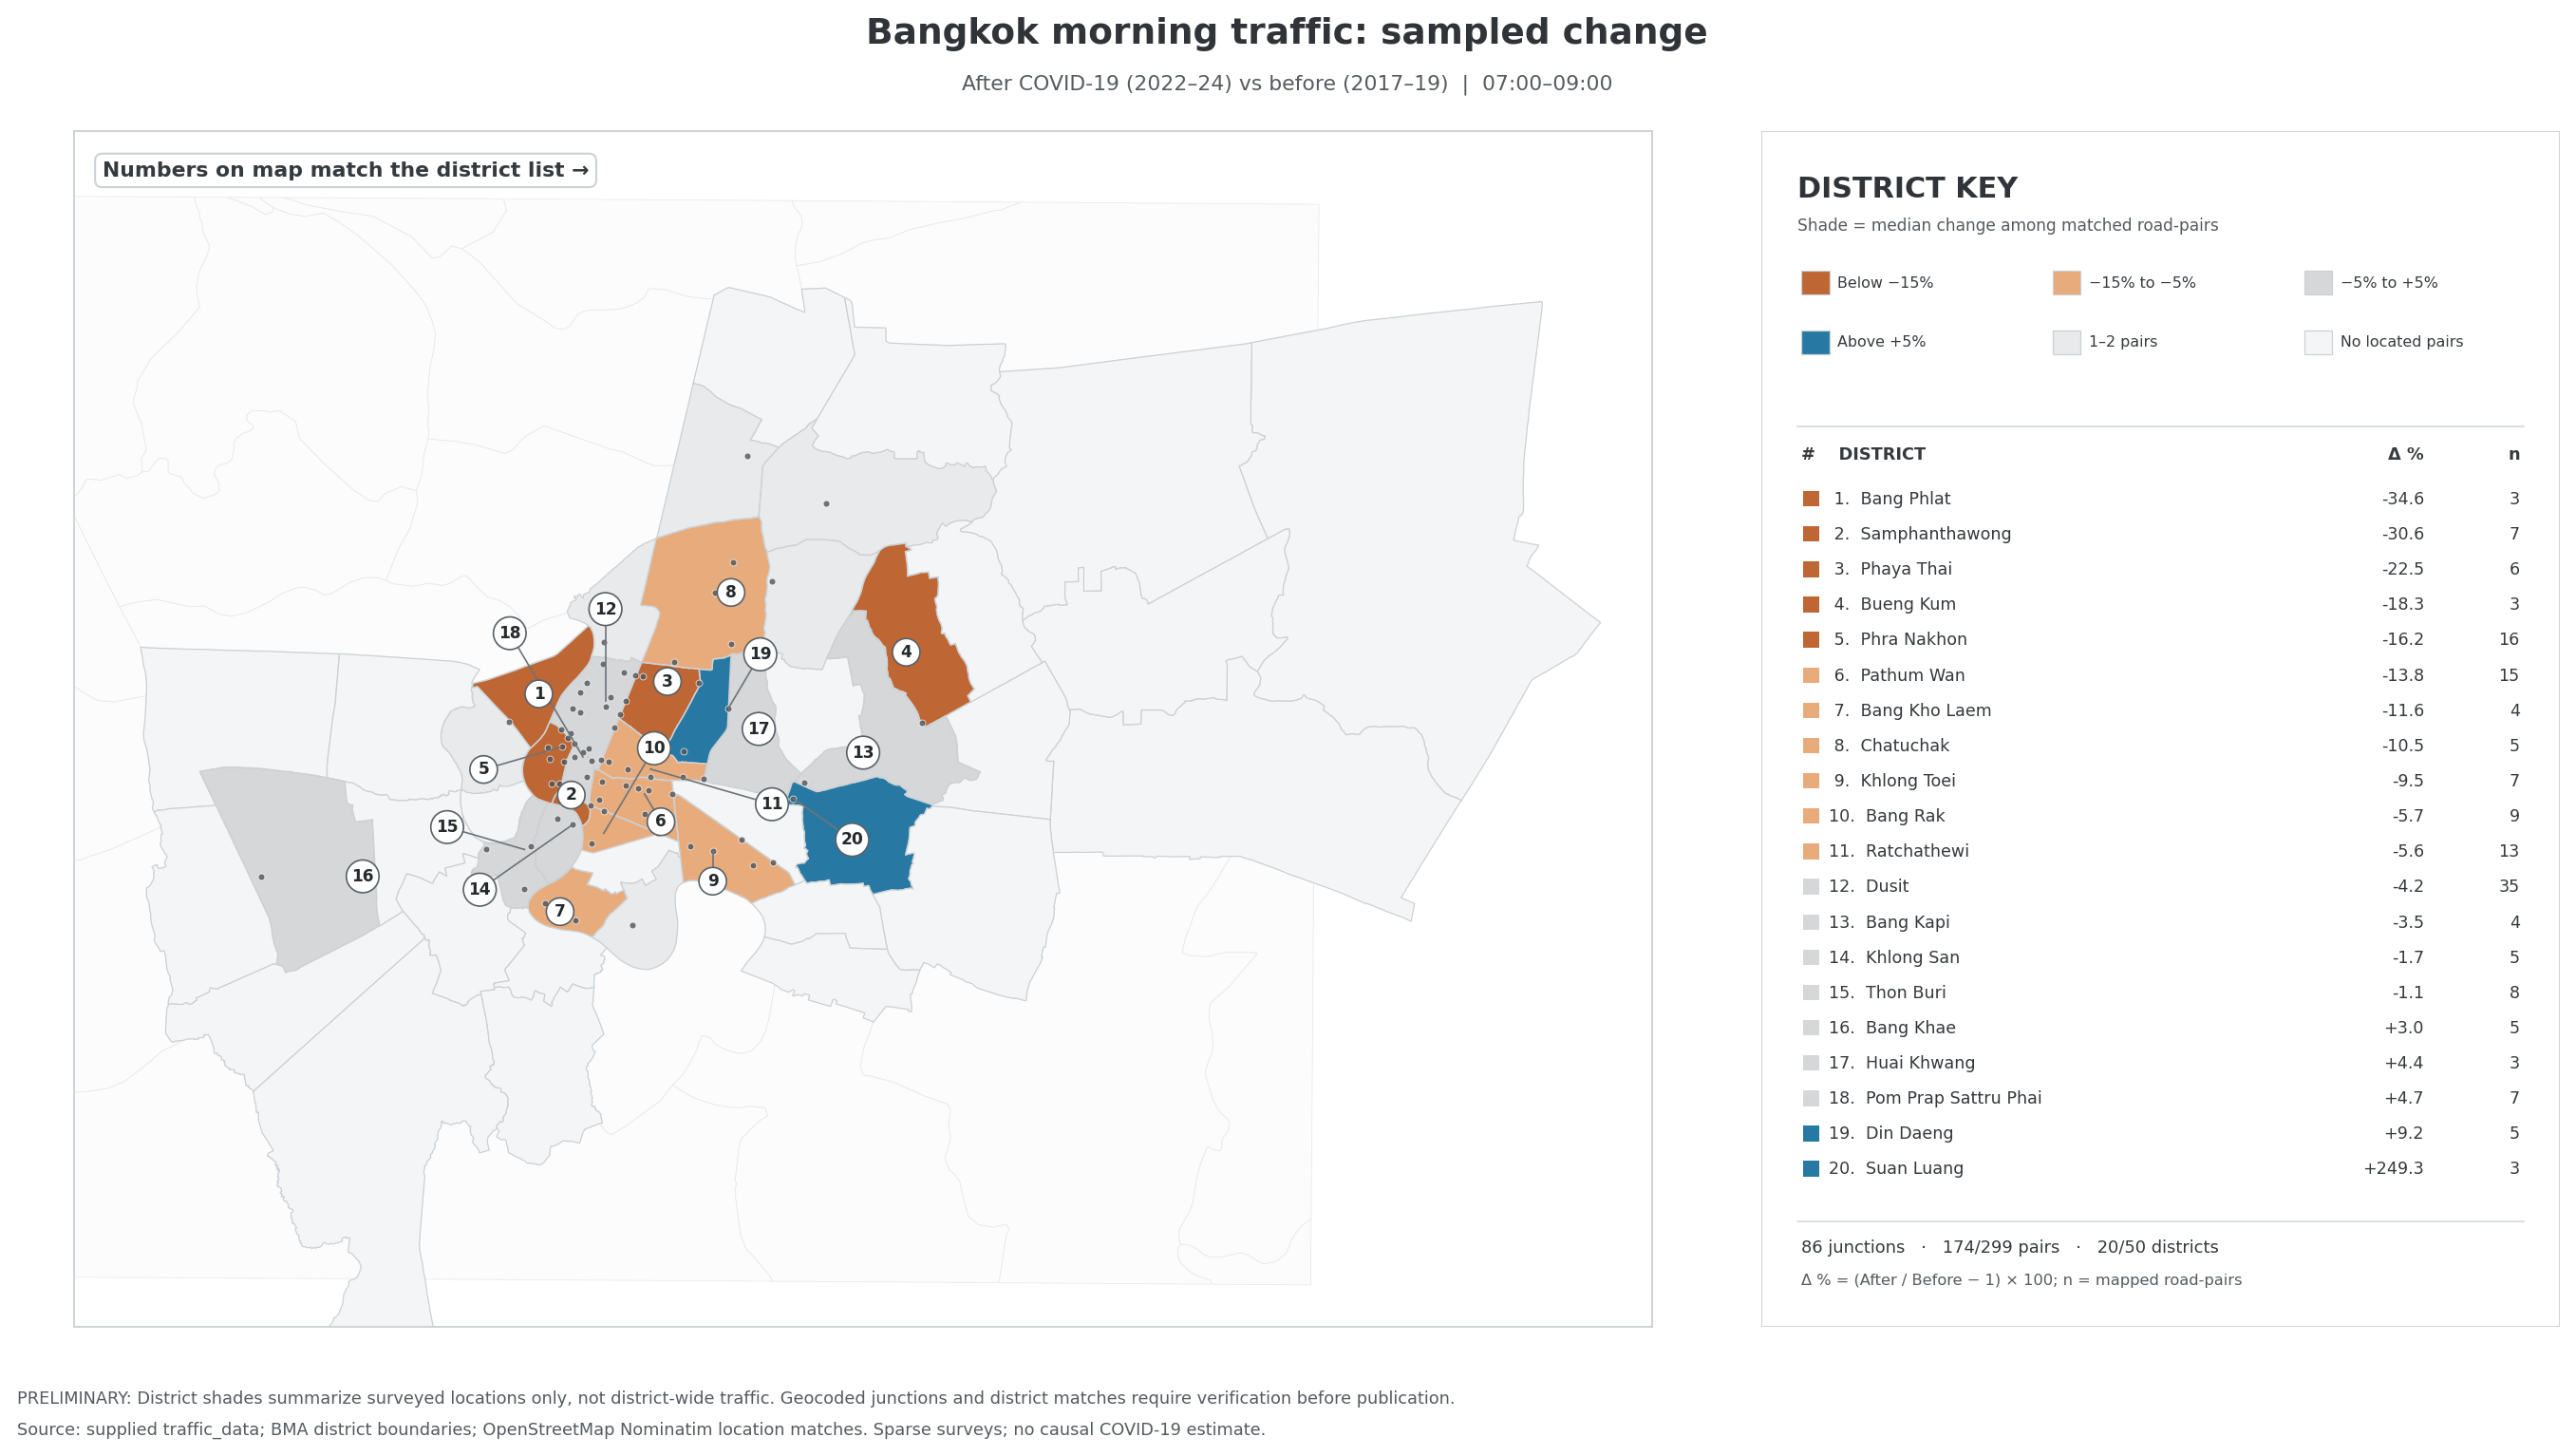

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
from IPython.display import display, Image
display(Image(filename=str(TRAFFIC_OUTPUT_PATH)))
files.download(str(TRAFFIC_OUTPUT_PATH))
